## **Retrieval Extraction with Embeddings and Cosine Similarity (Without Generation)**

Retrieval: Retrieve the most relevant passage or context based on the input question using embeddings and cosine similarity.

Extraction: Extracting the most relevant answer based on embeddings and cosine similarity, without any augmentation or generation steps.

Result: The answer is extracted directly from the context provided by the retrieved passage. The answer is simply the most relevant passage based on similarity.There is no generative model involved.

## Embeddings

**all-MiniLM-L6-v2**: A lightweight, transformer-based model for generating efficient and high-quality sentence embeddings, good for general-purpose NLP tasks.

In [1]:
!pip install -qqq ollama
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community
!pip install -qqq matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
print(os.getcwd())

/content


In [3]:
import requests
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from transformers import pipeline, AutoModel, AutoTokenizer
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
import ollama
import torch
from langchain_community.embeddings import OllamaEmbeddings
import subprocess
import json
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import DistilBertForQuestionAnswering, DistilBertTokenizer
from transformers import BartTokenizer, BartForConditionalGeneration
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Ensure directory exists
os.makedirs('./data/', exist_ok=True)

In [6]:
# Load the summary from the file
def load_summary(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()

# Main execution
summary_file_path = './data/msc_ai_keeleonline.txt'
loaded_summary = load_summary(summary_file_path)

# Print the loaded summary
print(loaded_summary)

=== Keele Online – MSc Computer Science with Artificial Intelligence ===

1. Overview
- Mode & Duration: 100 % online, part-time over 2 years (180 credits)
- Start Dates: Six intakes per year (next intake: 2 September 2025; application deadline: 19 August 2025; documents by 26 August 2025)
- Fees: Total £7,440; per 15‑credit module £620; final dissertation instalment £1,860; 10 % Keele alumni discount (£6,696)
- Payment Options: Per‑module or upfront; UK/EU students may apply for government postgraduate loans; fees reviewed annually

2. Entry Requirements
- Academic:
  • A 2:2 UK undergraduate degree (or international equivalent), OR
  • Third‑class honours / ordinary degree plus ≥2 years relevant work experience, OR
  • Non‑degree applicants: ≥3 years relevant computing/IT/data management experience
- English: If English isn’t first language, need one of:
  • IELTS 6.0 (min 5.5 each), TOEFL 79, PTE 50, Cambridge 169 (min 162 each), Duolingo 95 (min 85 each), OR
  • Degree taught in En

## Define Questions

In [7]:
questions = [
    "What is the delivery mode of the MSc Computer Science with Artificial Intelligence at Keele University?",
    "What is the tuition fee for the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Can the MSc Computer Science with Artificial Intelligence at Keele University be paid for in instalments?",
    "Can a UK postgraduate loan cover the MSc Computer Science with Artificial Intelligence at Keele University?",
    "What degree classification is normally required for the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Can relevant IT work experience replace a degree for entry to the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Is prior computer-science study a prerequisite for the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Which programming languages are taught on the MSc Computer Science with Artificial Intelligence at Keele University?",
    "How is assessment structured on the MSc Computer Science with Artificial Intelligence at Keele University?",
    "How many start dates per year are offered for the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Does the MSc Computer Science with Artificial Intelligence at Keele University require any campus attendance?",
    "Which scheduled study breaks are built into the MSc Computer Science with Artificial Intelligence at Keele University?",
    "What dedicated support does each student receive on the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Which core technical skills are developed through the MSc Computer Science with Artificial Intelligence at Keele University?",
    "Which email address should I contact about the MSc Computer Science with Artificial Intelligence at Keele University?",
    "What software is required for the MSc Computer Science with Artificial Intelligence at Keele University?"
]

ground_truth_answers = [
    "MSc Computer Science with Artificial Intelligence at Keele University is delivered 100 percent online.",
    "MSc Computer Science with Artificial Intelligence at Keele University costs £7,440.",
    "MSc Computer Science with Artificial Intelligence at Keele University can be paid in instalments.",
    "MSc Computer Science with Artificial Intelligence at Keele University can be funded by a UK postgraduate loan.",
    "MSc Computer Science with Artificial Intelligence at Keele University normally requires a 2 : 2 honours degree or equivalent.",
    "MSc Computer Science with Artificial Intelligence at Keele University accepts applicants with sufficient IT work experience instead of a degree.",
    "MSc Computer Science with Artificial Intelligence at Keele University does not require prior computer-science study.",
    "MSc Computer Science with Artificial Intelligence at Keele University teaches HTML, JavaScript, Java, Matlab, R and Python.",
    "MSc Computer Science with Artificial Intelligence at Keele University is assessed entirely by coursework.",
    "MSc Computer Science with Artificial Intelligence at Keele University offers six start dates each year.",
    "MSc Computer Science with Artificial Intelligence at Keele University requires no campus attendance.",
    "MSc Computer Science with Artificial Intelligence at Keele University includes winter and summer breaks.",
    "MSc Computer Science with Artificial Intelligence at Keele University assigns every student a Student Success Coordinator.",
    "MSc Computer Science with Artificial Intelligence at Keele University develops skills in AI, machine learning, data analytics, programming and software engineering.",
    "Enquiries about the MSc Computer Science with Artificial Intelligence at Keele University should be sent to enrolments@online.keele.ac.uk.",
    "MSc Computer Science with Artificial Intelligence at Keele University requires Microsoft Office, Anaconda, WEKA and XAMPP."
]


## A. Retrieval Extraction with 'all-'MiniLM'-v2' Embeddings and Cosine Similarity:

all-MiniLM-L6-v2' is a lightweight version of a transformer model designed for generating sentence embeddings, based on the architecture of transformer models like BERT, RoBERTa, DistilBERT.

"MiniLM" in the model name refers to Microsoft's MiniLM (Miniature Language Model).

**1. Embedding Process**:
all-MiniLM-L6-v2 used to generate sentence embeddings for questions and corresponding answers.
The embeddings created using SentenceTransformer, and cosine similarity is computed between question embedding and answer embeddings.

**2.Retrieval Process**:

For each question, computes cosine similarity between question's embedding and each answer's embedding.
The answer with highest cosine similarity score is selected as the most relevant answer.

**3. Evaluation**:

*Exact Match (EM) Score*calculated by comparing each retrieved answer to the ground truth answer. If they match exactly, it's considered a correct match.

*F1 Score*: This score measures the overlap between the tokens in the retrieved answer and the ground truth answer, considering both precision (how much of  retrieved answer is relevant) and recall (how much of relevant answer was retrieved).

### A1. Embedding Process

In [10]:
# Function to generate embeddings, find most relevant answers, save

def perform_embeddings(embedding_model_name, questions, answers):
    model = SentenceTransformer(embedding_model_name) # Load embedding model
    answer_embeddings = model.encode(answers, convert_to_tensor=True)  # Generate embeddings for answers

    predictions = []

    for question in questions:
        question_embedding = model.encode(question, convert_to_tensor=True) # Generate embedding for question
        similarities = util.pytorch_cos_sim(question_embedding, answer_embeddings)  # Compute cosine similarity between QnA
        most_similar_index = similarities.argmax() # Find index of most similar answer
        most_relevant_answer = answers[most_similar_index]  # Retrieve most relevant answer

        predictions.append(most_relevant_answer)

        print(f"Q: {question}\nA: {most_relevant_answer}\n")

    return predictions, answer_embeddings

### A2.Retrieval Process:

In [11]:
# Define model name
embedding_model_name = "all-MiniLM-L6-v2"

# Perform QA with MiniLM embeddings
predictions, MiniLM_embeddings = perform_embeddings(embedding_model_name, questions, ground_truth_answers)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Q: What is the delivery mode of the MSc Computer Science with Artificial Intelligence at Keele University?
A: Enquiries about the MSc Computer Science with Artificial Intelligence at Keele University should be sent to enrolments@online.keele.ac.uk.

Q: What is the tuition fee for the MSc Computer Science with Artificial Intelligence at Keele University?
A: MSc Computer Science with Artificial Intelligence at Keele University costs £7,440.

Q: Can the MSc Computer Science with Artificial Intelligence at Keele University be paid for in instalments?
A: MSc Computer Science with Artificial Intelligence at Keele University can be paid in instalments.

Q: Can a UK postgraduate loan cover the MSc Computer Science with Artificial Intelligence at Keele University?
A: MSc Computer Science with Artificial Intelligence at Keele University can be funded by a UK postgraduate loan.

Q: What degree classification is normally required for the MSc Computer Science with Artificial Intelligence at Keele U

#### Save the "all-MiniLM-L6-v2" embeddings

In [13]:
# Save embeddings
embedding_file_path = './data/MiniLM_embeddings_keele.pkl'

with open(embedding_file_path, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)

print(f"Embeddings saved to {embedding_file_path}")

Embeddings saved to ./data/MiniLM_embeddings_keele.pkl


#### Load and print the saved "all-MiniLM-L6-v2" embeddings from the file

In [14]:
# Path to embeddings file
embedding_file_path = './data/MiniLM_embeddings_keele.pkl'

# Load embeddings from file
with open(embedding_file_path, 'rb') as f:
    loaded_embeddings = pickle.load(f)

print(f"Embeddings loaded from {embedding_file_path}:") # Print loaded embeddings
print(loaded_embeddings)

Embeddings loaded from ./data/MiniLM_embeddings_keele.pkl:
tensor([[-0.0632, -0.0316,  0.0070,  ..., -0.0153,  0.0222, -0.0037],
        [-0.0567, -0.0529,  0.0647,  ..., -0.1430, -0.0103, -0.0325],
        [-0.0673, -0.0367,  0.0638,  ..., -0.1199,  0.0394, -0.0471],
        ...,
        [-0.0452, -0.0451,  0.0357,  ...,  0.0030, -0.0129, -0.0061],
        [-0.0567, -0.0755,  0.0352,  ..., -0.0054, -0.0485, -0.0199],
        [-0.0581, -0.0749,  0.0052,  ..., -0.0077,  0.0152, -0.0252]])


### A3. Evaluation:

### Calculates the Exact Match (EM) Score and F1 Score for a retrieval-based extraction task using all-MiniLM-L6-v2 embeddings and cosine similarity.

Exact Match (EM) Score: Measures proportion of exactly matching answers between  retrievals and the ground truths.

F1 Score: Measures overlap between the retrieved and ground truth answers in terms of shared tokens, balancing precision and recall.

In [16]:
# Function to calculate Exact Match and F1 Score
def evaluate(predictions, ground_truths):
    em_score = sum([1 if pred == truth else 0 for pred, truth in zip(predictions, ground_truths)]) / len(ground_truths)

    f1_scores = []
    for pred, truth in zip(predictions, ground_truths):
        pred_tokens = pred.split()
        truth_tokens = truth.split()
        common_tokens = set(pred_tokens) & set(truth_tokens)
        if len(common_tokens) == 0:
            f1_scores.append(0)
        else:
            precision = len(common_tokens) / len(pred_tokens)
            recall = len(common_tokens) / len(truth_tokens)
            f1 = 2 * (precision * recall) / (precision + recall)
            f1_scores.append(f1)

    f1_score_avg = sum(f1_scores) / len(f1_scores)

    return em_score, f1_score_avg

# Evaluate the predictions
em_score, f1_score_avg = evaluate(predictions, ground_truth_answers)
print(f"Exact Match (EM) Score: {em_score:.2f}")
print(f"F1 Score: {f1_score_avg:.2f}")

Exact Match (EM) Score: 0.69
F1 Score: 0.85


### A4.Visualization:

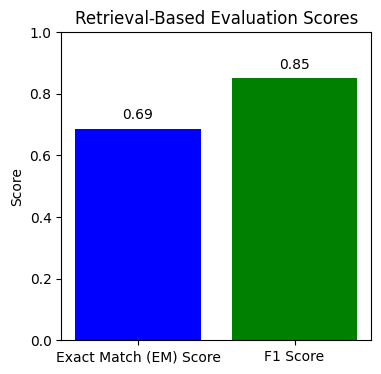

In [17]:
# Visualize the EM and F1 scores using a bar chart
scores = [em_score, f1_score_avg]
score_labels = ['Exact Match (EM) Score', 'F1 Score']

plt.figure(figsize=(4, 4))
bars = plt.bar(score_labels, scores, color=['blue', 'green'])
plt.ylim(0, 1)  # Since scores are between 0 and 1
plt.title('Retrieval-Based Evaluation Scores')
plt.ylabel('Score')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.show()

### Interpretation:

The high Exact Match (EM) Score and F1 Score for certain questions whose answers are available in the knowledge base suggests that the retrieval-based model with cosine similarity performs adequately when relevant material is present.



In [18]:
import os
os.makedirs('./data/', exist_ok=True)
print("Directory './data/' is ready.")

Directory './data/' is ready.


In [19]:
# Save embeddings with backup option to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check the embedding object
print(f'Type: {type(MiniLM_embeddings)}, Length: {len(MiniLM_embeddings)}')

# Save to local
embedding_file_local = './data/MiniLM_embeddings_keele.pkl'
with open(embedding_file_local, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)
print(f"Embeddings saved locally to {embedding_file_local}")

# Save to Google Drive
embedding_file_drive = '/content/drive/MyDrive/HULL/Thesis/CODES/gradio_apps/Retrieval_Based_Chatbot_Hull_Keele/data/MiniLM_embeddings_keele.pkl'
with open(embedding_file_drive, 'wb') as f:
    pickle.dump(MiniLM_embeddings, f)
print(f"Embeddings also backed up to {embedding_file_drive}")

Mounted at /content/drive
Type: <class 'torch.Tensor'>, Length: 16
Embeddings saved locally to ./data/MiniLM_embeddings_keele.pkl
Embeddings also backed up to /content/drive/MyDrive/HULL/Thesis/CODES/gradio_apps/Retrieval_Based_Chatbot_Hull_Keele/data/MiniLM_embeddings_keele.pkl


In [20]:
# Load embeddings from Google Drive or local
embedding_file = '/content/drive/MyDrive/HULL/Thesis/CODES/gradio_apps/Retrieval_Based_Chatbot_Hull_Keele/data/MiniLM_embeddings_keele.pkl'
if os.path.exists(embedding_file):
    with open(embedding_file, 'rb') as f:
        loaded_embeddings = pickle.load(f)
    print(f"Embeddings loaded from {embedding_file}")
    print(f"Loaded embeddings type: {type(loaded_embeddings)}, Length: {len(loaded_embeddings)}")
else:
    print(f"Embedding file not found at {embedding_file}")

Embeddings loaded from /content/drive/MyDrive/HULL/Thesis/CODES/gradio_apps/Retrieval_Based_Chatbot_Hull_Keele/data/MiniLM_embeddings_keele.pkl
Loaded embeddings type: <class 'torch.Tensor'>, Length: 16


In [21]:
import os
os.makedirs('./data/', exist_ok=True)
print("Directory './data/' is ready.")

Directory './data/' is ready.
